In [13]:
# Automatically reload the package if you edit the .py files
%load_ext autoreload
%autoreload 2

import warnings; warnings.filterwarnings("ignore") # remove scanpy warnings for the tutorial.
# Import the new package name
import decipher_vz as dc_vz

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
dc_vz.pl.activate_journal_quality()

# Load data

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scanpy as sc 

In [4]:
import matplotlib
print(matplotlib.__version__)
import IPython
print(IPython.__version__)

3.10.8
9.12.0


# simulated data

In [12]:
folder = "/Users/jihyunpark/Documents/Decipher/decipher-bc/Data/Simulated Data/Simulated Adata/v-to-z"
file = "v_to_z_0.20_0.40_0.60.h5ad"
adata1 = sc.read_h5ad(f"{folder}/{file}")
adata1.uns["color_palette"] = None
color_palette = None

Epoch 225 (batch 20/20) | | train elbo: 97.78 (last epoch: 96.99) | val ll: 109.39:  22%|██▎       | 225/1000 [02:11<07:33,  1.71it/s]2026-06-15 16:35:30,838 | INFO : Early stopping has been triggered.
2026-06-15 16:35:30,842 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-06-15 16:35:30,843 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-06-15 16:35:30,843 | INFO : Saving decipher model with run_id 2026-06-15-16-35-30-dyadic-khaki-juice.


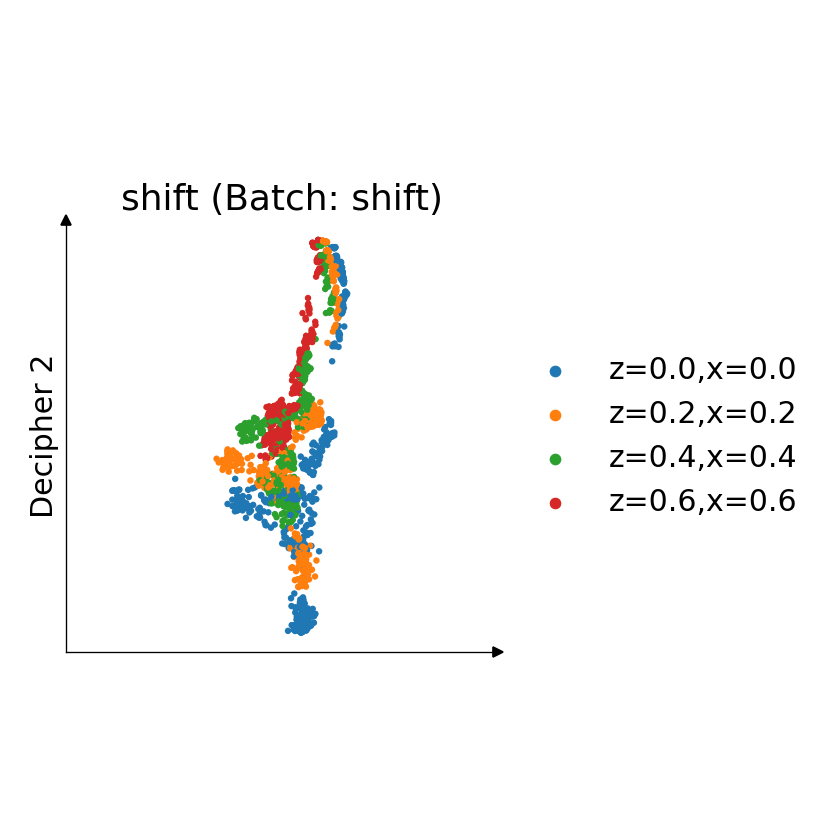

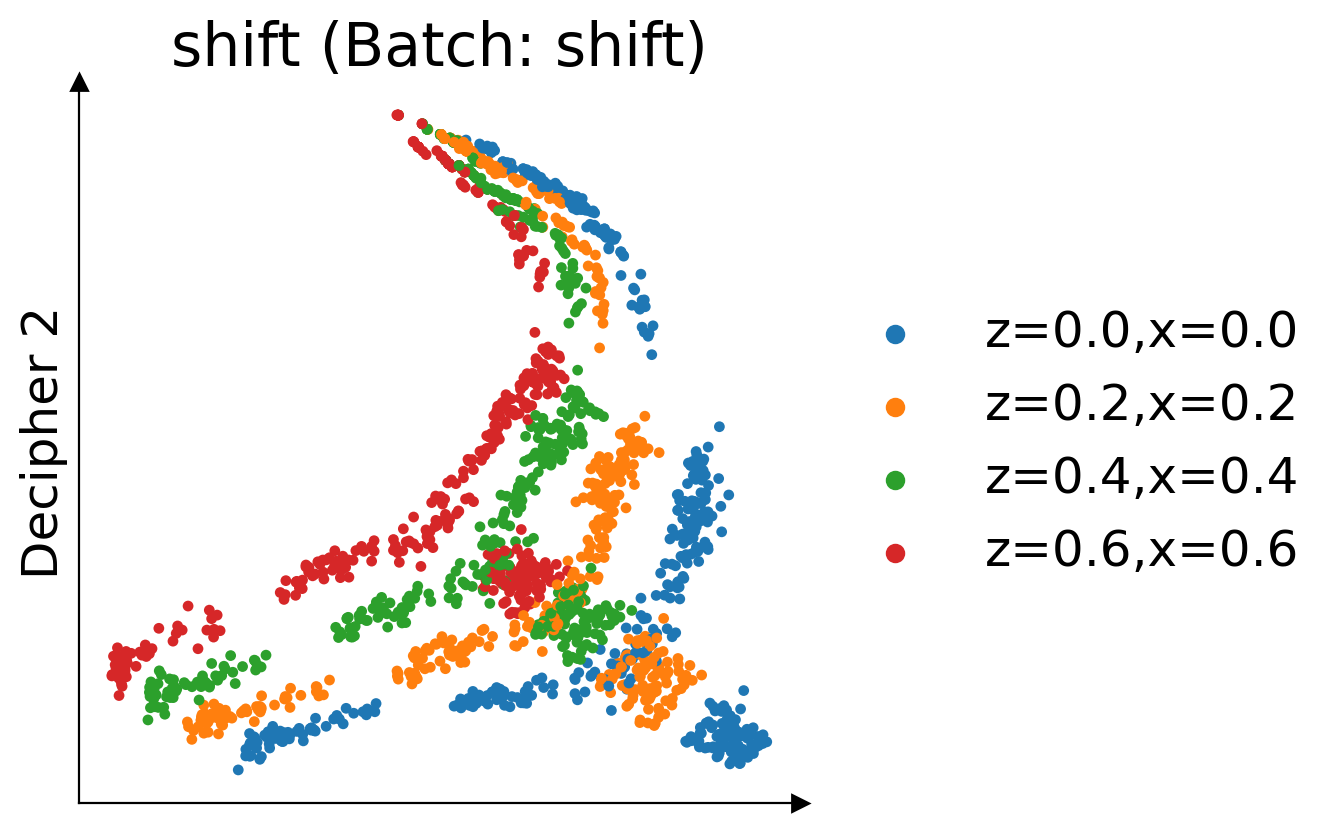

In [14]:
from decipher_vz.tools._decipher import DecipherConfig
decipher_config = DecipherConfig(learning_rate=1e-3, seed=1)

# Train Decipher
d1, val1 = dc_vz.tl.decipher_train(
    adata1, decipher_config, plot_kwargs= {"color": "shift"}, 
    batch_key="shift",
    plot_every_k_epochs=5,
)

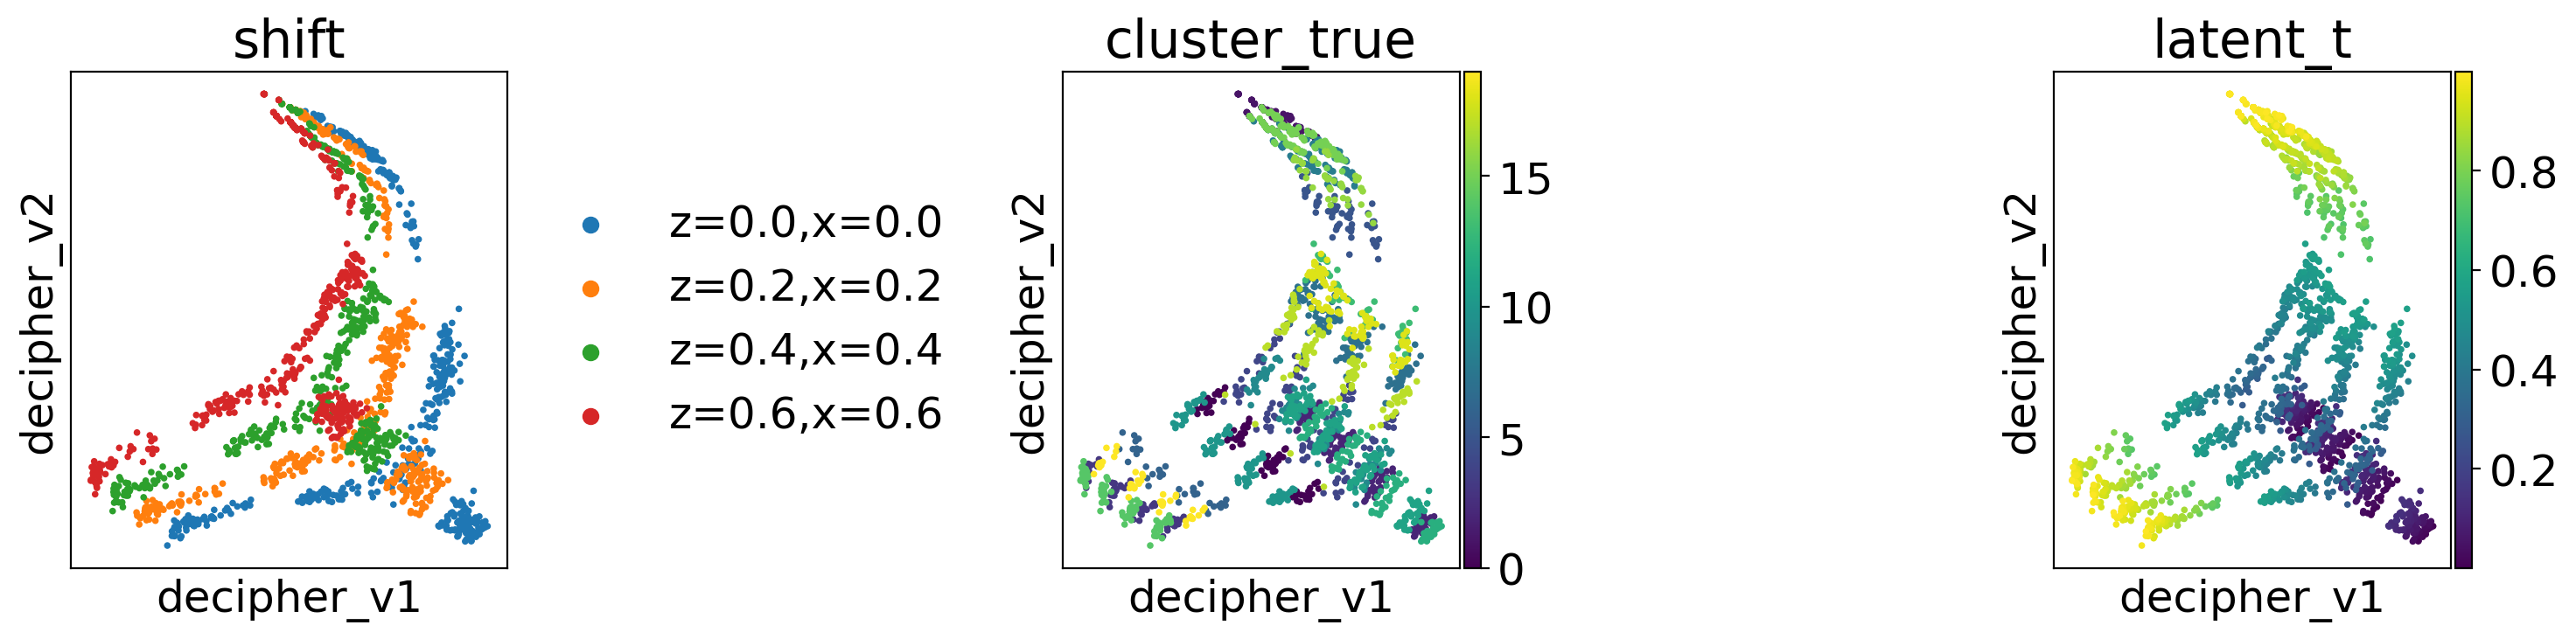

In [19]:
import logging
import pandas as pd
import scanpy as sc
import os
from sklearn.cluster import KMeans

from matplotlib import pyplot as plt
import seaborn as sns

import matplotlib as mpl

import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from scipy.sparse.csgraph import minimum_spanning_tree
from sklearn.metrics import silhouette_samples

decipher_z = adata1.obsm["decipher_z"]
k_means = KMeans(20)
k_means.fit(decipher_z)
adata1.obs["cluster_latent"] = k_means.labels_

aris = {}
for a in adata1.obs["shift"].unique():
    mask = adata1.obs["shift"] == a
    aris[a] = adjusted_rand_score(
        adata1.obs["cluster_true"][mask],
        adata1.obs["cluster_latent"][mask],
    )
#print(f"[{suffix}] aris values: {aris}")

shift_labels = adata1.obs["shift"]
# sil_values = silhouette_samples(decipher_z, shift_labels)
# df = pd.DataFrame({"silhouette_value": sil_values, "alpha": shift_labels.values})
# print(df.groupby("alpha", observed=True)["silhouette_value"].mean())

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(5*3, 4))
# sc.pl.embedding(adata1, basis="decipher_v", color="shift",
#                 show=False, ax=axes[0], size=30)
sc.pl.embedding(adata1, basis="decipher_v", color="shift",
                show=False, ax=axes[0], size=30)
sc.pl.embedding(adata1, basis="decipher_v", color="cluster_true",
                show=False, ax=axes[1], size=30)
sc.pl.embedding(adata1, basis="decipher_v", color="latent_t",
                show=False, ax=axes[2], size=30)
plt.tight_layout()
plt.show()

In [23]:
folder = "/Users/jihyunpark/Documents/Decipher/decipher-bc/Data/Simulated Data/Simulated Adata/z-to-x"
file = "delta_0.40_0.80_1.20.h5ad"
adata3 = sc.read_h5ad(f"{folder}/{file}")
adata3.uns["color_palette"] = None
color_palette = None

Epoch 248 (batch 20/20) | | train elbo: 134.45 (last epoch: 134.61) | val ll: 145.00:  25%|██▍       | 248/1000 [12:31<37:58,  3.03s/it]2026-06-15 18:40:28,070 | INFO : Early stopping has been triggered.


2026-06-15 18:40:28,451 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-06-15 18:40:28,460 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-06-15 18:40:28,480 | INFO : Saving decipher model with run_id 2026-06-15-18-40-28-recursive-tranquil-ice.


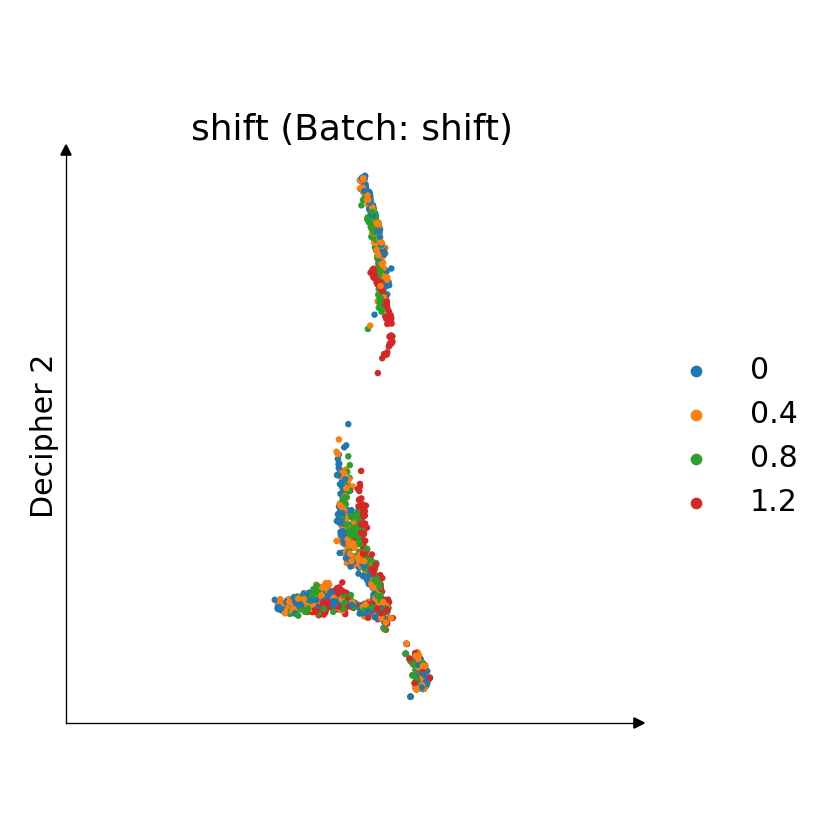

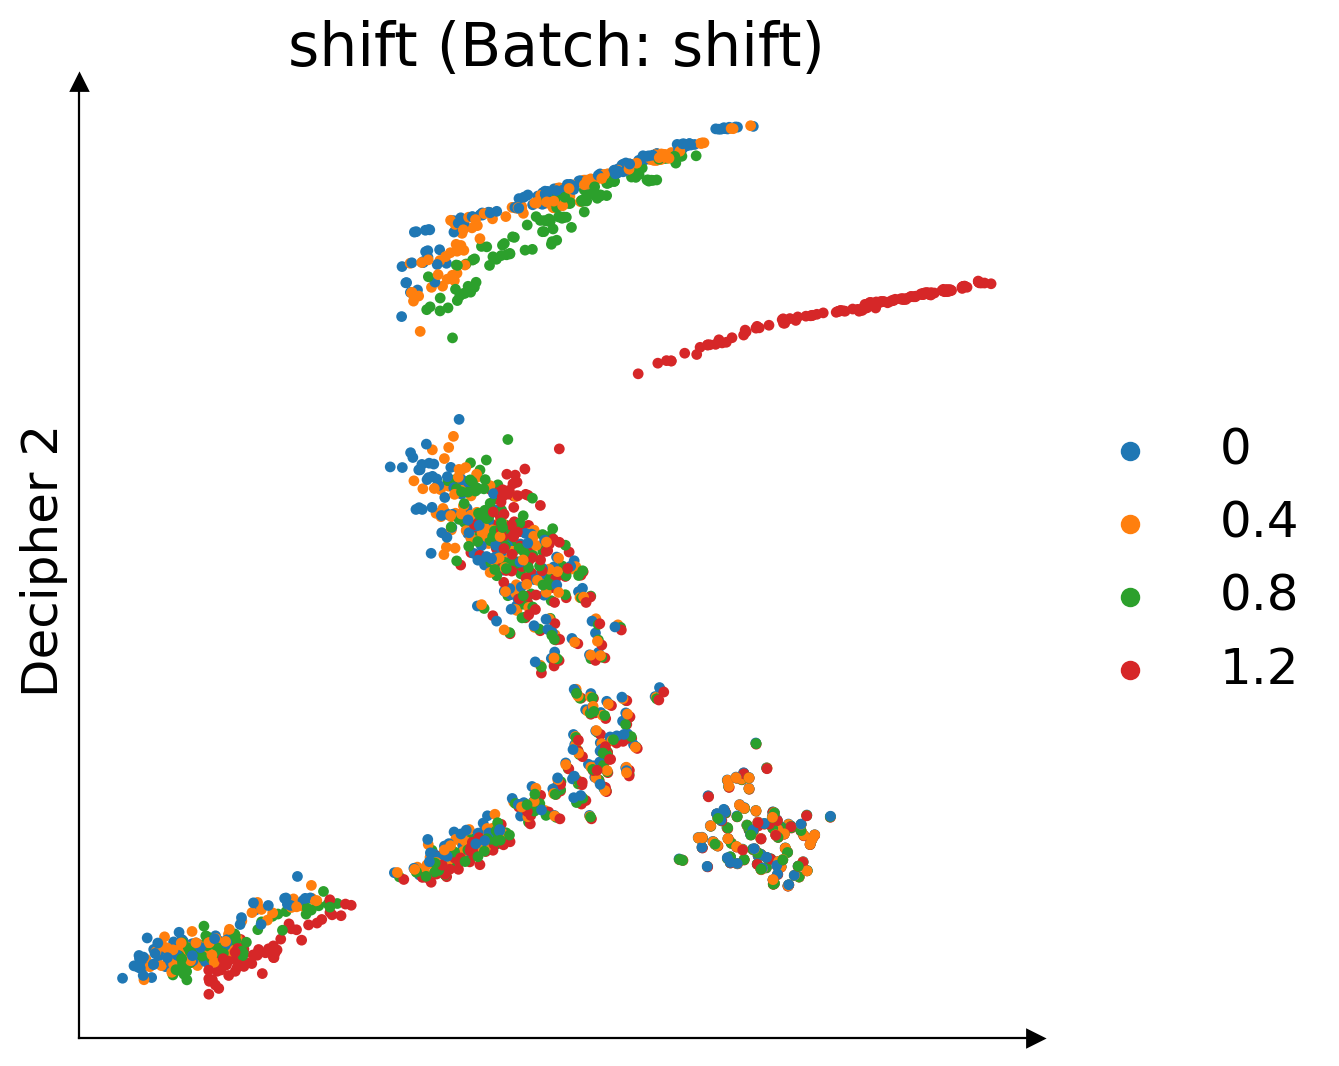

In [24]:
from decipher_vz.tools._decipher import DecipherConfig
decipher_config = DecipherConfig(learning_rate=1e-3, seed=1)

# Train Decipher
d3, val3 = dc_vz.tl.decipher_train(
    adata3, decipher_config, plot_kwargs= {"color": "shift"}, 
    batch_key="shift",
    plot_every_k_epochs=5,
)

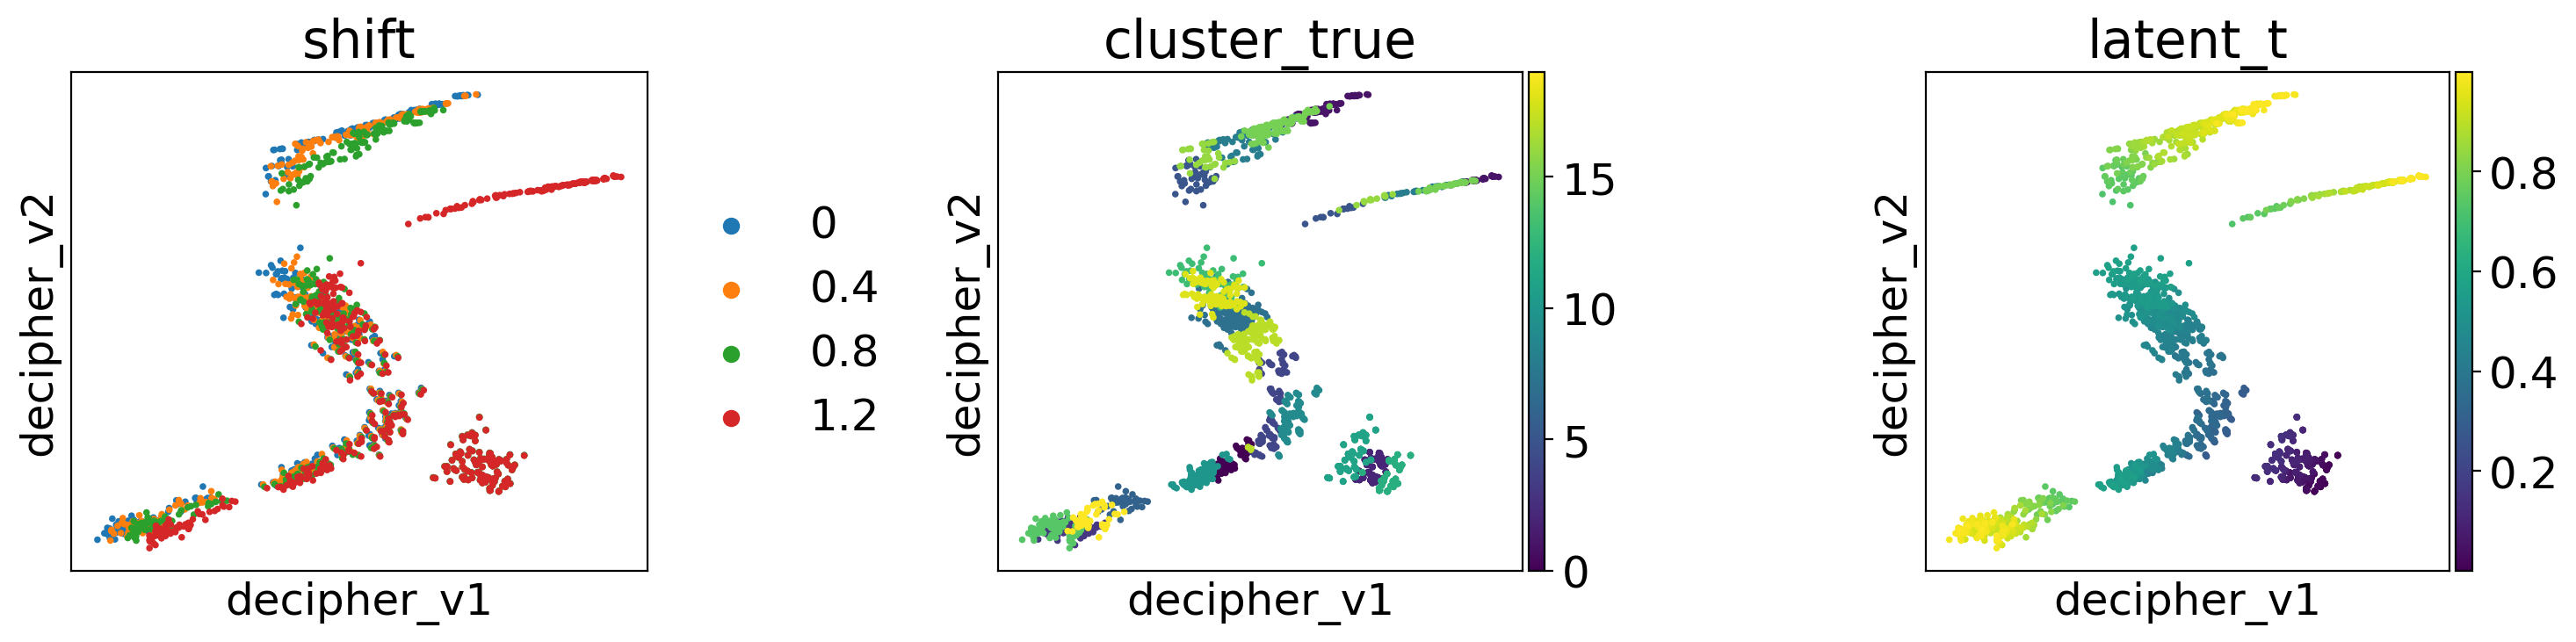

In [25]:
temp = adata3.copy()

decipher_z = temp.obsm["decipher_z"]
k_means = KMeans(20)
k_means.fit(decipher_z)
temp.obs["cluster_latent"] = k_means.labels_

aris = {}
for a in temp.obs["shift"].unique():
    mask = temp.obs["shift"] == a
    aris[a] = adjusted_rand_score(
        temp.obs["cluster_true"][mask],
        temp.obs["cluster_latent"][mask],
    )
#print(f"[{suffix}] aris values: {aris}")

shift_labels = temp.obs["shift"]
# sil_values = silhouette_samples(decipher_z, shift_labels)
# df = pd.DataFrame({"silhouette_value": sil_values, "alpha": shift_labels.values})
# print(df.groupby("alpha", observed=True)["silhouette_value"].mean())

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(5*3, 4))
# sc.pl.embedding(temp, basis="decipher_v", color="shift",
#                 show=False, ax=axes[0], size=30)
sc.pl.embedding(temp, basis="decipher_v", color="shift",
                show=False, ax=axes[0], size=30)
sc.pl.embedding(temp, basis="decipher_v", color="cluster_true",
                show=False, ax=axes[1], size=30)
sc.pl.embedding(temp, basis="decipher_v", color="latent_t",
                show=False, ax=axes[2], size=30)
plt.tight_layout()
plt.show()

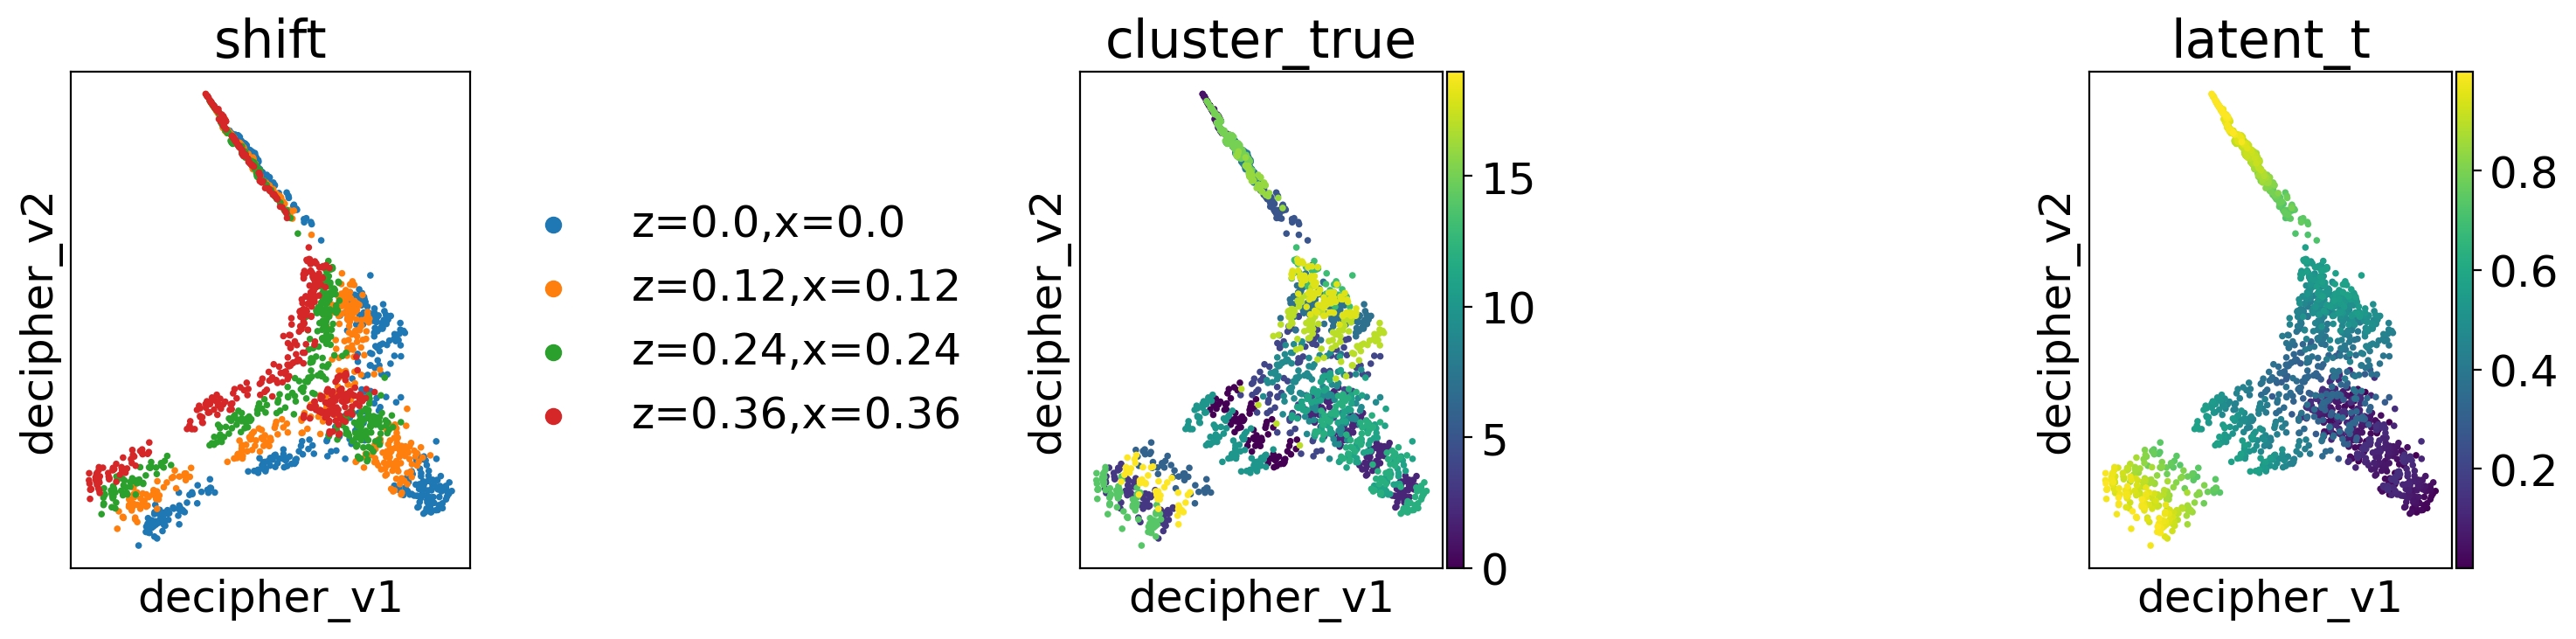

In [22]:
import logging
import pandas as pd
import scanpy as sc
import os
from sklearn.cluster import KMeans

from matplotlib import pyplot as plt
import seaborn as sns

import matplotlib as mpl

import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from scipy.sparse.csgraph import minimum_spanning_tree
from sklearn.metrics import silhouette_samples


temp = adata2.copy()

decipher_z = temp.obsm["decipher_z"]
k_means = KMeans(20)
k_means.fit(decipher_z)
temp.obs["cluster_latent"] = k_means.labels_

aris = {}
for a in temp.obs["shift"].unique():
    mask = temp.obs["shift"] == a
    aris[a] = adjusted_rand_score(
        temp.obs["cluster_true"][mask],
        temp.obs["cluster_latent"][mask],
    )
#print(f"[{suffix}] aris values: {aris}")

shift_labels = temp.obs["shift"]
# sil_values = silhouette_samples(decipher_z, shift_labels)
# df = pd.DataFrame({"silhouette_value": sil_values, "alpha": shift_labels.values})
# print(df.groupby("alpha", observed=True)["silhouette_value"].mean())

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(5*3, 4))
# sc.pl.embedding(temp, basis="decipher_v", color="shift",
#                 show=False, ax=axes[0], size=30)
sc.pl.embedding(temp, basis="decipher_v", color="shift",
                show=False, ax=axes[0], size=30)
sc.pl.embedding(temp, basis="decipher_v", color="cluster_true",
                show=False, ax=axes[1], size=30)
sc.pl.embedding(temp, basis="decipher_v", color="latent_t",
                show=False, ax=axes[2], size=30)
plt.tight_layout()
plt.show()

In [ ]:
file = "v_to_z_0.12_0.24_0.36.h5ad"
adata2 = sc.read_h5ad(f"{folder}/{file}")
adata2.uns["color_palette"] = None
color_palette = None

In [18]:
from decipher.tools._decipher import DecipherConfig
decipher_config = DecipherConfig(learning_rate=1e-3, seed=1)

# Train Decipher
d1, val1 = dc.tl.decipher_train(
    adata1, decipher_config, plot_kwargs= {"color": "shift"}, 
    plot_every_k_epochs=5,
)

2026-06-15 16:36:46,356 | INFO : Added `.obs['decipher_split']`: the Decipher train/validation split.
 200 cells in validation set.
  0%|          | 0/1000 [00:00<?, ?it/s]

ERROR index_select(): self indexing axis dim should be positive
                                  Trace Shapes:           
                                   Param Sites:           
                         decipher$$$dummy_param       0   
                    decipher$$$batch_emb.weight   0   8   
      decipher$$$encoder_x_to_z.layers.0.weight 128  50   
        decipher$$$encoder_x_to_z.layers.0.bias     128   
      decipher$$$encoder_x_to_z.layers.1.weight  20 128   
        decipher$$$encoder_x_to_z.layers.1.bias      20   
 decipher$$$encoder_x_to_z.batch_norms.0.weight     128   
   decipher$$$encoder_x_to_z.batch_norms.0.bias     128   
     decipher$$$encoder_zx_to_v.layers.0.weight 128  60   
       decipher$$$encoder_zx_to_v.layers.0.bias     128   
     decipher$$$encoder_zx_to_v.layers.1.weight   4 128   
       decipher$$$encoder_zx_to_v.layers.1.bias       4   
decipher$$$encoder_zx_to_v.batch_norms.0.weight     128   
  decipher$$$encoder_zx_to_v.batch_norms.0.bias    

In [68]:
# Before choosing what to correct for, measure which covariates actually drive
# separation in the v-space. High silhouette = strong separation = bigger effect.

from sklearn.metrics import silhouette_score

v = adata_combined.obsm['decipher_v'].copy()

# Only score covariates with at least 2 unique values and no NaNs
covariates_to_score = {
    "shift"   : adata_combined.obs["shift"].astype(str),
}

print("\n── Silhouette scores in v-space (higher = stronger separation) ──────────")
silhouette_results = {}
for name, labels in covariates_to_score.items():
    # Drop NaN rows
    mask = labels != "nan"
    if labels[mask].nunique() < 2:
        print(f"  {name:<20} skipped (< 2 unique values)")
        continue
    score = silhouette_score(v[mask], labels[mask], sample_size=5000, random_state=42)
    silhouette_results[name] = score
    print(f"  {name:<25} silhouette = {score:.4f}")  



── Silhouette scores in v-space (higher = stronger separation) ──────────
  shift                     silhouette = -0.0487
